In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import sys; sys.path.insert(0, '..')
from utils import parse_latencies, parse_power_log, get_power_index, plot_inference_cycle_power

In [2]:
DATA_PATH = Path('../../raw_data/power_profile_model_loading')
DELAY = 1 # delay introduced in seconds between inference cycles

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 4174621.6927380087


## VGG16

In this section, we will analyse the power consumption of VGG16 model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.


In [4]:
model_name = 'vgg16'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
vgg16_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
vgg16_latency_data = parse_latencies(data)

with open((DATA_PATH/model_name/f'{model_name}_tensorrt.json'), 'r') as fp:
    data = json.load(fp)
vgg16_data = data

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:01<00:00, 31.08it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(vgg16_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(vgg16_latency_data[0])}")
print(f"Number of latency entries for each layer: {len(vgg16_latency_data)}")

Number of power entries for vgg16: 2716871
Number of TensorRT layers in vgg16: 37
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.2 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. This part of the plot will be investigated as part of different notebook.

In this notebook, we will look at the plot after 0.2.

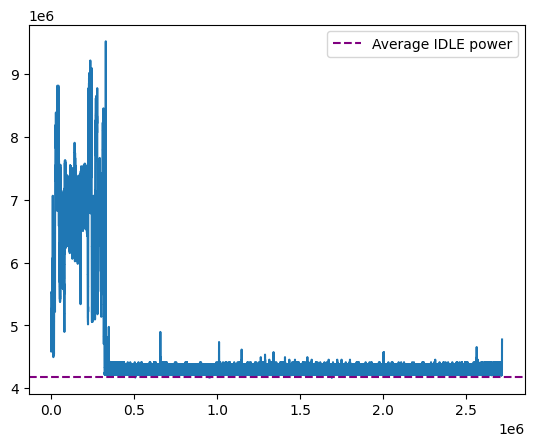

In [6]:
plt.plot([power for (timestamp, power) in vgg16_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [7]:
experiment_start_time = datetime.strptime(vgg16_data['timestamp'], "%Y%m%d-%H%M%S")
exp_start_time_index = get_power_index(vgg16_power_data, experiment_start_time)

pytorch_load_end_time = datetime.strptime(vgg16_data['pt_model_load_end'], "%Y%m%d-%H%M%S")
pytorch_load_end_index = get_power_index(vgg16_power_data, pytorch_load_end_time)

model_load_start_time = datetime.strptime(vgg16_data['model_load'][0], "%Y%m%d-%H%M%S")
model_load_start_index = get_power_index(vgg16_power_data, model_load_start_time)
model_load_end_time = datetime.strptime(vgg16_data['model_load'][1], "%Y%m%d-%H%M%S")
model_load_end_index = get_power_index(vgg16_power_data, model_load_end_time)

warmup_start_time = datetime.strptime(vgg16_data['warmup'][0], "%Y%m%d-%H%M%S")
warmup_start_index = get_power_index(vgg16_power_data, warmup_start_time)
warmup_end_time = datetime.strptime(vgg16_data['warmup'][1], "%Y%m%d-%H%M%S")
warmup_end_index = get_power_index(vgg16_power_data, warmup_end_time)

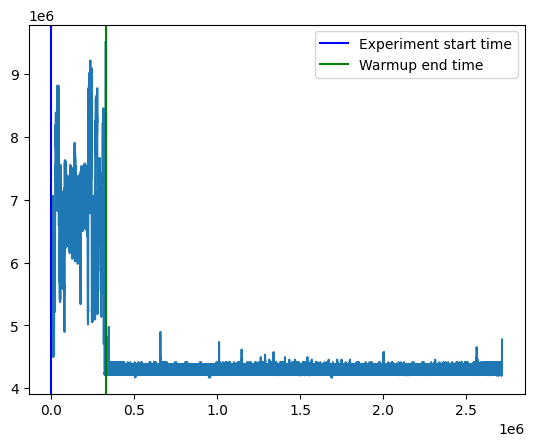

In [8]:
plt.plot([power for (timestamp, power) in vgg16_power_data])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(warmup_end_index, color='green', label='Warmup end time')
plt.legend()

### Observations

We will be looking at the intial spike in the power profile and breaking it down to understand what is happening in that phase.

We will capture timestamp when the 
- experiment has started
- model is being compiled and add a delay for 10 seconds
- when the warmup is being ran

The above timestamps will provide insights into what is going on with the initial timestamp.

The following plot shows the power profile when the experiment started and before the model is being compiled from PyTorch to TensorRT.

- The experiment starts at a higher power value which slowly decreases and increases.

What are things happening in this time?

- We get the PyTorch model downloaded
- Create dummy PyTorch input tensors
- Move both the model and the input tensors to GPU 

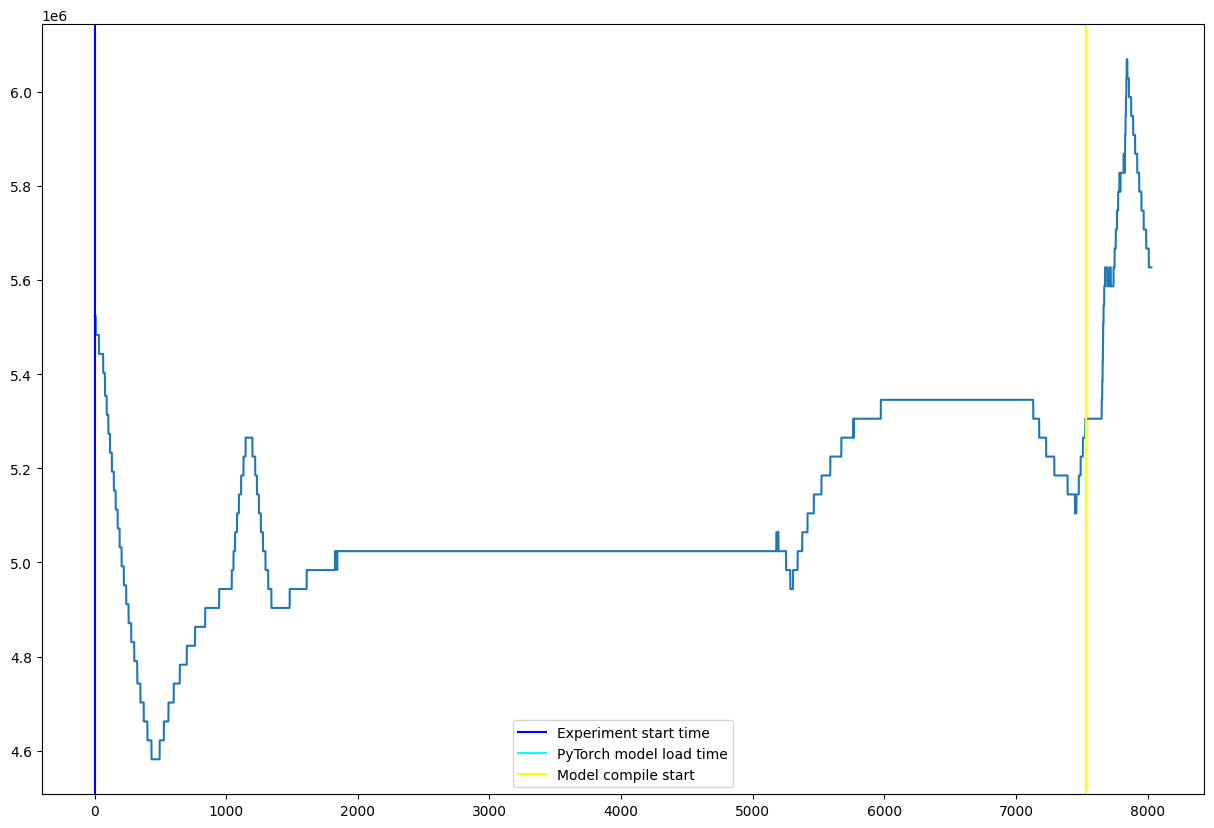

In [9]:
plt.figure(figsize=(15, 10))
plt.plot([power for (timestamp, power) in vgg16_power_data[:model_load_start_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(pytorch_load_end_index, color='cyan', label='PyTorch model load time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.legend()

This is the most interesting plot that shows all the things happening before the actual inference starts.

1. Load the PyTorch model and peparate it for converting it to TensorRT. -> **This is the part between blue and yellow line.**
2. Convert the PyTorch model to TensorRT model. -> **This is the part between yellow and red line**.
3. A delay of 10 seconds is added as a cooldown from compilation. -> **This is the part between red and green line**.
4. A warmup of 100 runs is pretty fast. -> **This is the part between purple and green line**. It is fast so the lines are overlapping.

In the following section we break down the actual time taken by these processes as well.

We can also get the power consumed when the model is loaded which is 3rd part above between red and green line.
We get that power value to be `4213440.0`.

So we have power value 

- When jeston is idle : 4174621
- When TRT model is loaded: 4213440
- When inference is ran for 3000 runs: 4213440  -> **Same power value as when TRT model is loaded**

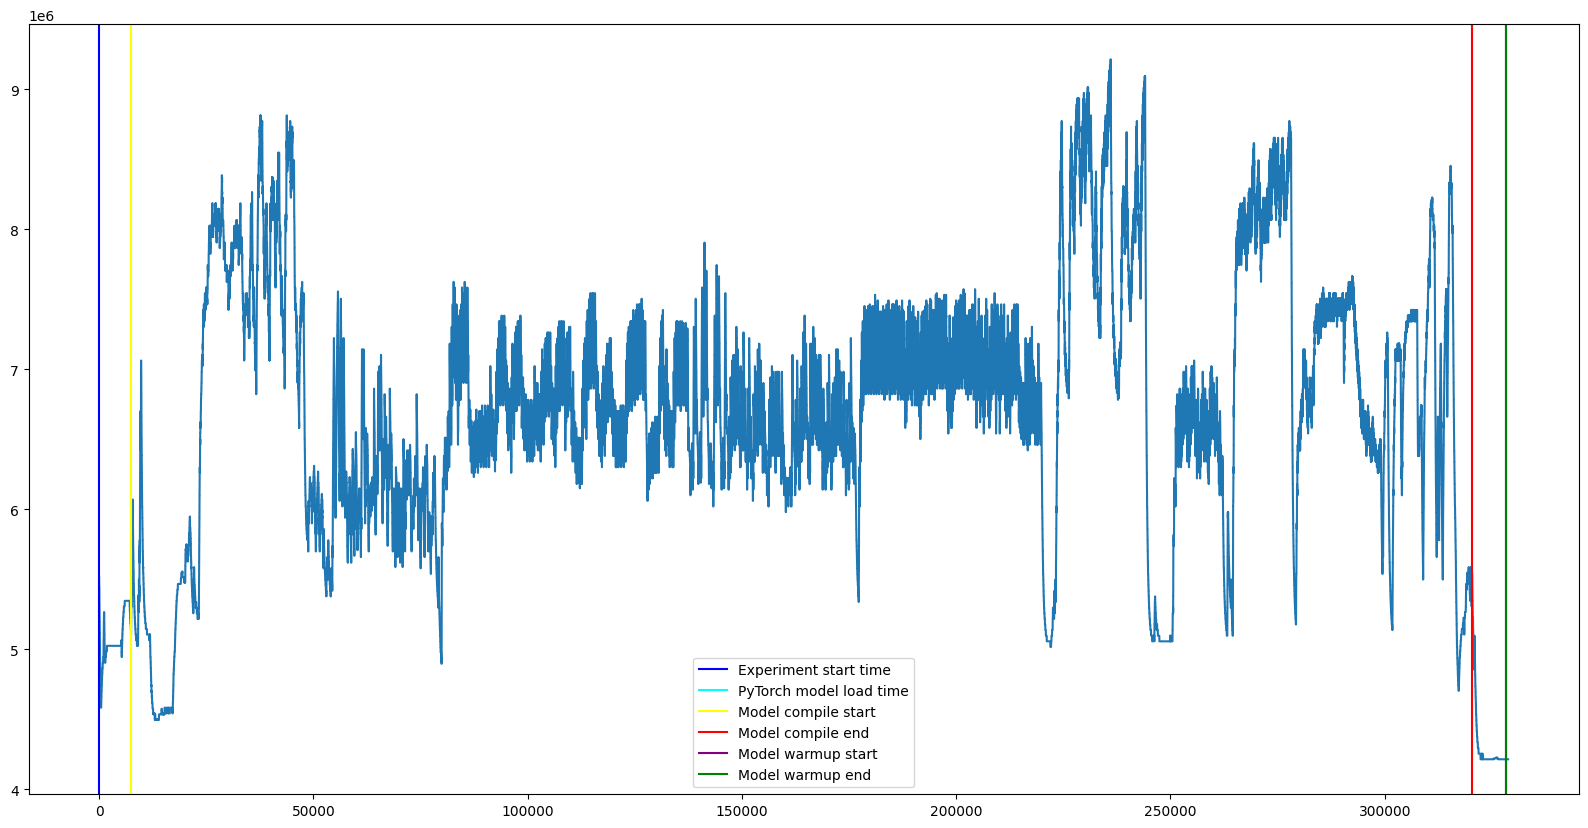

In [10]:
plt.figure(figsize=(20, 10))
plt.plot([power for (timestamp, power) in vgg16_power_data[:warmup_end_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(pytorch_load_end_index, color='cyan', label='PyTorch model load time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.axvline(model_load_end_index, color='red', label='Model compile end')
plt.axvline(warmup_start_index, color='purple', label='Model warmup start')
plt.axvline(warmup_end_index, color='green', label='Model warmup end')
plt.legend()

In [11]:
print(f'Time taken to download and load the pytorch model: {(pytorch_load_end_time - experiment_start_time).total_seconds()} seconds')
print(f'Time taken to before the model compile starts and pytorch model is loaded: {(model_load_start_time - pytorch_load_end_time).total_seconds()} seconds')
print(f'Time taken to compile the TensorRT model: {(model_load_end_time - model_load_start_time).total_seconds()} seconds')
print(f'Sleep interval before the warmup starts: {(warmup_start_time - model_load_end_time).total_seconds()} seconds')
print(f'Time taken to run 100 runs of the warmup: {(warmup_end_time - warmup_start_time).total_seconds()} seconds')

Time taken to download and load the pytorch model: 11.0 seconds
Time taken to before the model compile starts and pytorch model is loaded: 0.0 seconds
Time taken to compile the TensorRT model: 407.0 seconds
Sleep interval before the warmup starts: 10.0 seconds
Time taken to run 100 runs of the warmup: 0.0 seconds


### Power cool down

This is the delay we introduce after the warmup ends and before the first iteration cycle beings for the benchmarking experiment.

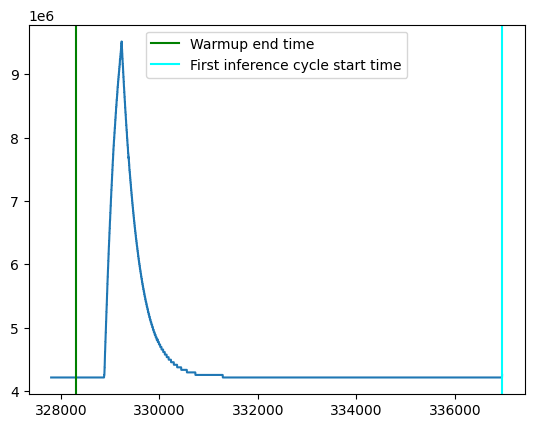

In [12]:
plt.plot(range(warmup_end_index-500, 336960), [power for (timestamp, power) in vgg16_power_data[warmup_end_index-500:336960]])
plt.axvline(warmup_end_index, color='green', label='Warmup end time')
plt.axvline(336960, color='cyan', label='First inference cycle start time')
plt.legend()

### Inference


Something else that is interesting is now the first cylce like the rest of the cycles has similar power profile for the inference.

By adding sufficient delays and allowing the power to cool down, we see that inference for 3000 runs consumes the same power for all cycles. 


> **The power consumed when the inference starts is different.**

> **The power at the end of inference is significantly higher than inference start.**

> **The power at the end of 1 second delay significantly lower than inference end.**

2025-01-22 15:27:57.004080 -> 2025-01-22 15:27:57.012842
2025-01-22 15:27:58.012842
Time taken by inference cycle 0: 0:00:00.008762
Iteration: 0, Power index: 336960 -> 336967
337754


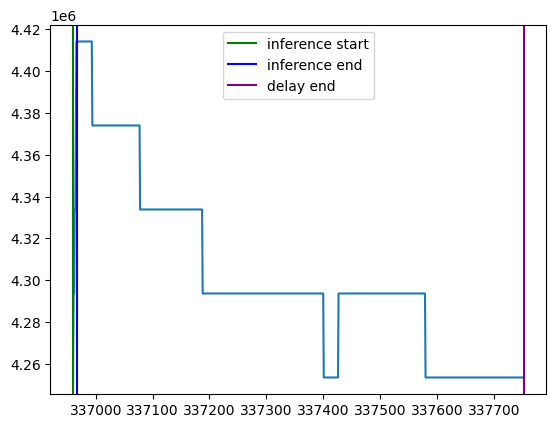

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:27:58.027078 -> 2025-01-22 15:27:58.035755
2025-01-22 15:27:59.035755
Time taken by inference cycle 1: 0:00:00.008677
Iteration: 1, Power index: 337764 -> 337772
338559


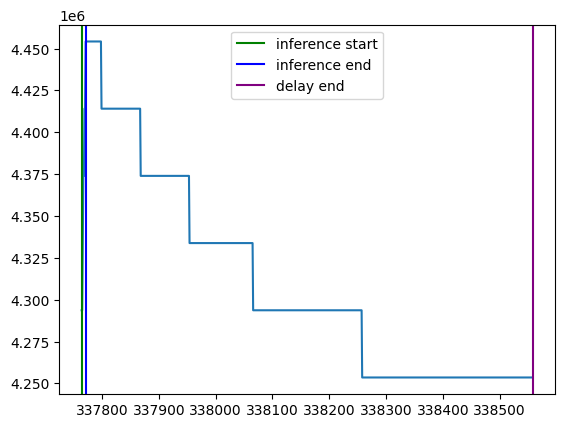

Power values:
Inference start: 4293696.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:27:59.038846 -> 2025-01-22 15:27:59.047494
2025-01-22 15:28:00.047494
Time taken by inference cycle 2: 0:00:00.008648
Iteration: 2, Power index: 338561 -> 338569
339356


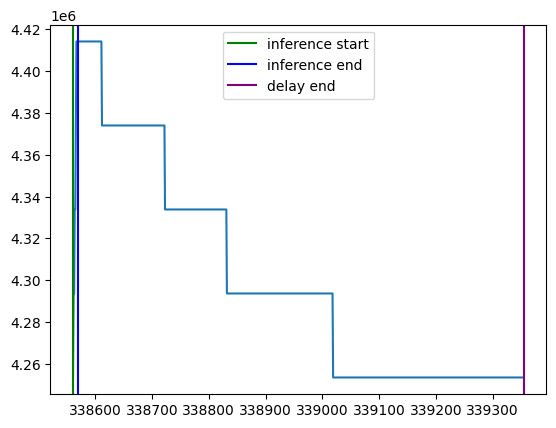

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:00.050387 -> 2025-01-22 15:28:00.059093
2025-01-22 15:28:01.059093
Time taken by inference cycle 3: 0:00:00.008706
Iteration: 3, Power index: 339357 -> 339365
340153


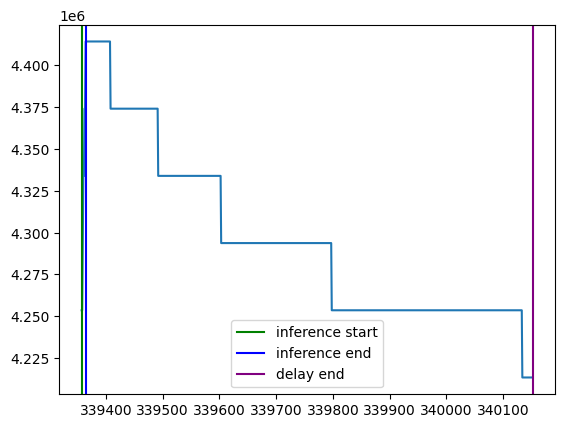

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:01.061904 -> 2025-01-22 15:28:01.070595
2025-01-22 15:28:02.070595
Time taken by inference cycle 4: 0:00:00.008691
Iteration: 4, Power index: 340154 -> 340162
340949


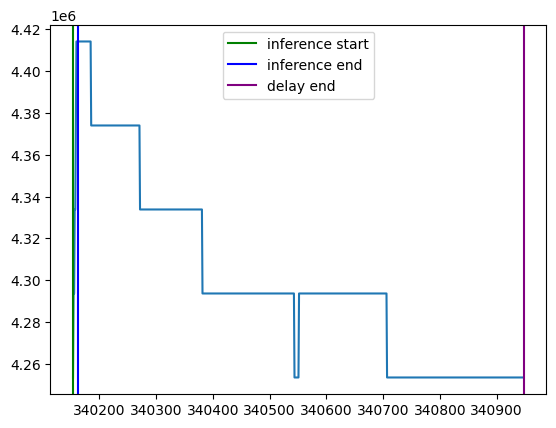

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:02.073551 -> 2025-01-22 15:28:02.082255
2025-01-22 15:28:03.082255
Time taken by inference cycle 5: 0:00:00.008704
Iteration: 5, Power index: 340950 -> 340958
341746


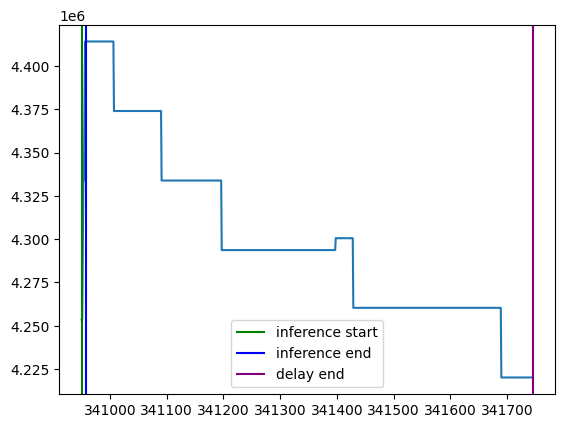

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:03.085116 -> 2025-01-22 15:28:03.093813
2025-01-22 15:28:04.093813
Time taken by inference cycle 6: 0:00:00.008697
Iteration: 6, Power index: 341747 -> 341755
342541


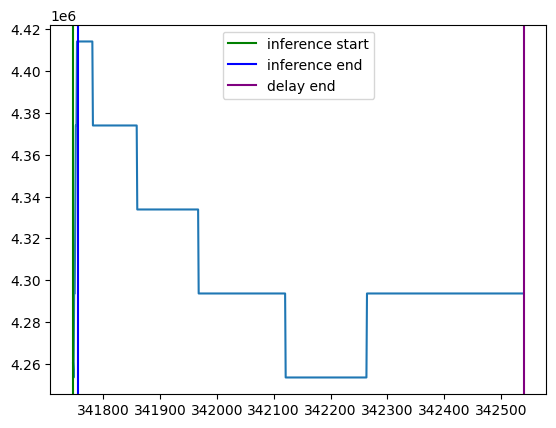

Power values:
Inference start: 4260352.0
Inference end: 4414080.0
Delay end: 4293696.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:04.096952 -> 2025-01-22 15:28:04.105885
2025-01-22 15:28:05.105885
Time taken by inference cycle 7: 0:00:00.008933
Iteration: 7, Power index: 342542 -> 342550
343328


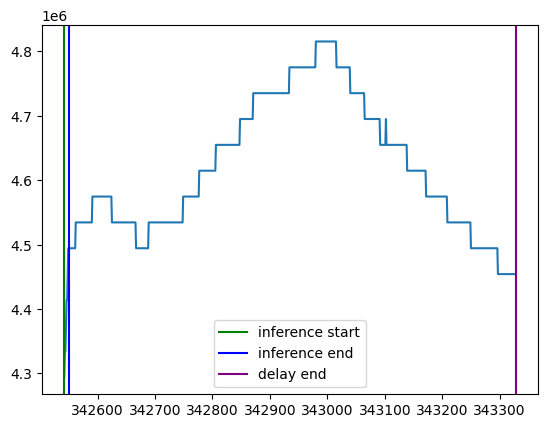

Power values:
Inference start: 4293696.0
Inference end: 4494336.0
Delay end: 4454208.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:05.109525 -> 2025-01-22 15:28:05.118178
2025-01-22 15:28:06.118178
Time taken by inference cycle 8: 0:00:00.008653
Iteration: 8, Power index: 343330 -> 343338
344119


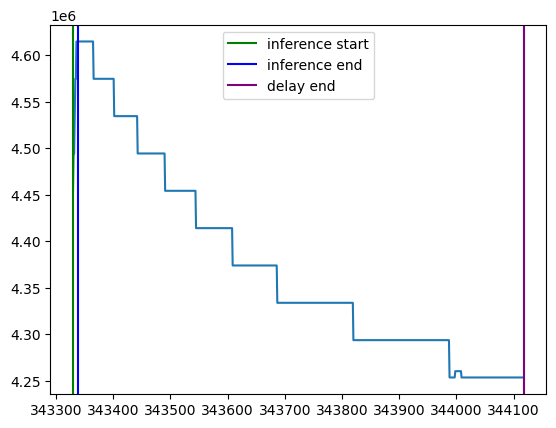

Power values:
Inference start: 4454208.0
Inference end: 4614720.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:06.120828 -> 2025-01-22 15:28:06.129369
2025-01-22 15:28:07.129369
Time taken by inference cycle 9: 0:00:00.008541
Iteration: 9, Power index: 344121 -> 344128
344911


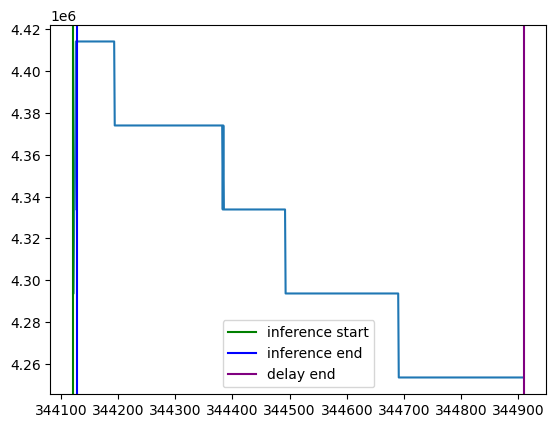

Power values:
Inference start: 4293696.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:07.132658 -> 2025-01-22 15:28:07.141305
2025-01-22 15:28:08.141305
Time taken by inference cycle 10: 0:00:00.008647
Iteration: 10, Power index: 344913 -> 344920
345702


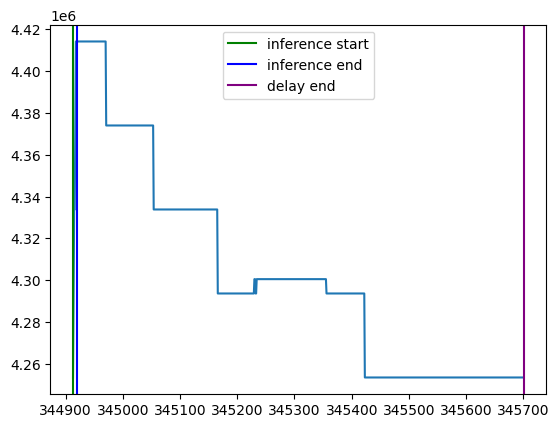

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:08.144385 -> 2025-01-22 15:28:08.153070
2025-01-22 15:28:09.153070
Time taken by inference cycle 11: 0:00:00.008685
Iteration: 11, Power index: 345704 -> 345712
346494


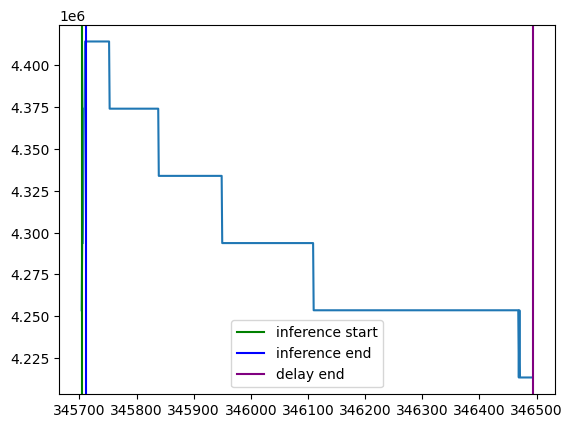

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:09.156044 -> 2025-01-22 15:28:09.164887
2025-01-22 15:28:10.164887
Time taken by inference cycle 12: 0:00:00.008843
Iteration: 12, Power index: 346495 -> 346503
347275


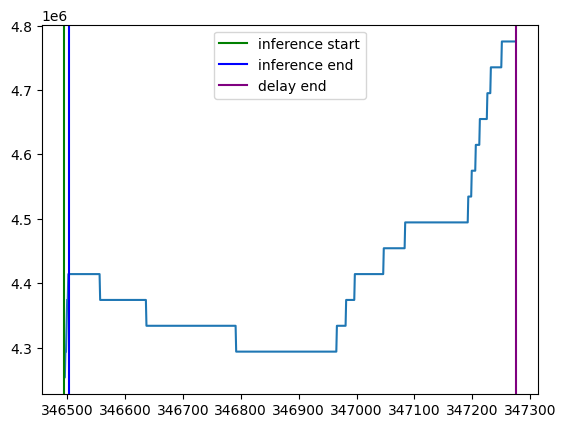

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4775232.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:10.168794 -> 2025-01-22 15:28:10.177431
2025-01-22 15:28:11.177431
Time taken by inference cycle 13: 0:00:00.008637
Iteration: 13, Power index: 347277 -> 347285
348069


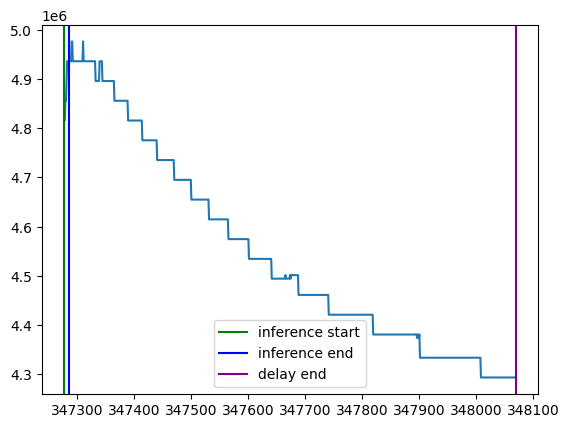

Power values:
Inference start: 4815360.0
Inference end: 4935744.0
Delay end: 4293696.0
----------------------------------------------------------------------------------------------------
2025-01-22 15:28:11.181007 -> 2025-01-22 15:28:11.189880
2025-01-22 15:28:12.189880
Time taken by inference cycle 14: 0:00:00.008873
Iteration: 14, Power index: 348070 -> 348078
348866


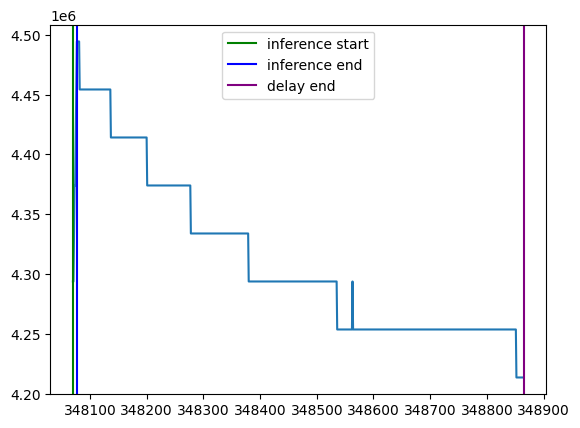

Power values:
Inference start: 4293696.0
Inference end: 4494336.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------


In [13]:
for i in range(15):
    plot_inference_cycle_power(i, vgg16_power_data, vgg16_latency_data, DELAY)

## VGG19

In this section, we will analyse the power consumption of VGG19 model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.


In [14]:
model_name = 'vgg19'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
vgg19_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
vgg19_latency_data = parse_latencies(data)

with open((DATA_PATH/model_name/f'{model_name}_tensorrt.json'), 'r') as fp:
    data = json.load(fp)
vgg19_data = data

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:01<00:00, 30.53it/s]


In [15]:
print(f"Number of power entries for {model_name}: {len(vgg19_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(vgg19_latency_data[0])}")
print(f"Number of latency entries for each layer: {len(vgg19_latency_data)}")

Number of power entries for vgg19: 2724104
Number of TensorRT layers in vgg19: 40
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.2 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. 

This part of the plot will be investigated as part of this notebook.

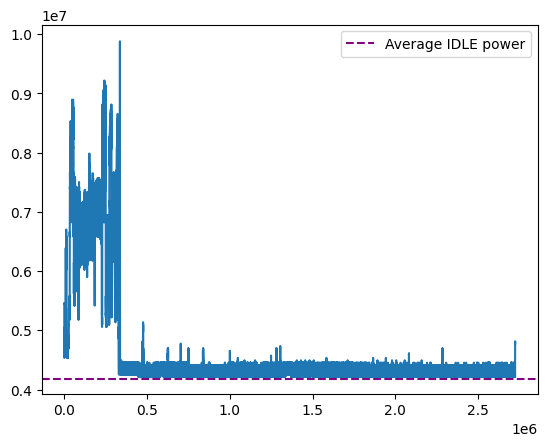

In [16]:
plt.plot([power for (timestamp, power) in vgg19_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [17]:
experiment_start_time = datetime.strptime(vgg19_data['timestamp'], "%Y%m%d-%H%M%S")
exp_start_time_index = get_power_index(vgg19_power_data, experiment_start_time)

pytorch_load_end_time = datetime.strptime(vgg19_data['pt_model_load_end'], "%Y%m%d-%H%M%S")
pytorch_load_end_index = get_power_index(vgg19_power_data, pytorch_load_end_time)

model_load_start_time = datetime.strptime(vgg19_data['model_load'][0], "%Y%m%d-%H%M%S")
model_load_start_index = get_power_index(vgg19_power_data, model_load_start_time)
model_load_end_time = datetime.strptime(vgg19_data['model_load'][1], "%Y%m%d-%H%M%S")
model_load_end_index = get_power_index(vgg19_power_data, model_load_end_time)

warmup_start_time = datetime.strptime(vgg19_data['warmup'][0], "%Y%m%d-%H%M%S")
warmup_start_index = get_power_index(vgg19_power_data, warmup_start_time)
warmup_end_time = datetime.strptime(vgg19_data['warmup'][1], "%Y%m%d-%H%M%S")
warmup_end_index = get_power_index(vgg19_power_data, warmup_end_time)

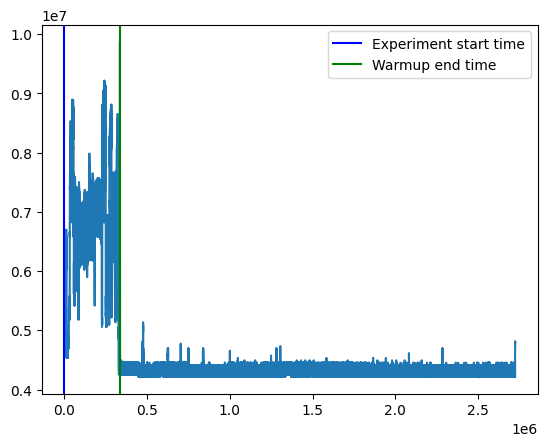

In [18]:
plt.plot([power for (timestamp, power) in vgg19_power_data])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(warmup_end_index, color='green', label='Warmup end time')
plt.legend()

### Observations

We will be looking at the intial spike in the power profile and breaking it down to understand what is happening in that phase.

We will capture timestamp when the 
- experiment has started
- model is being compiled and add a delay for 10 seconds
- when the warmup is being ran

The above timestamps will provide insights into what is going on with the initial timestamp.

The following plot shows the power profile when the experiment started and before the model is being compiled from PyTorch to TensorRT.

- The experiment starts at a higher power value which slowly decreases and increases.

What are things happening in this time?

- We get the PyTorch model downloaded
- Create dummy PyTorch input tensors
- Move both the model and the input tensors to GPU 

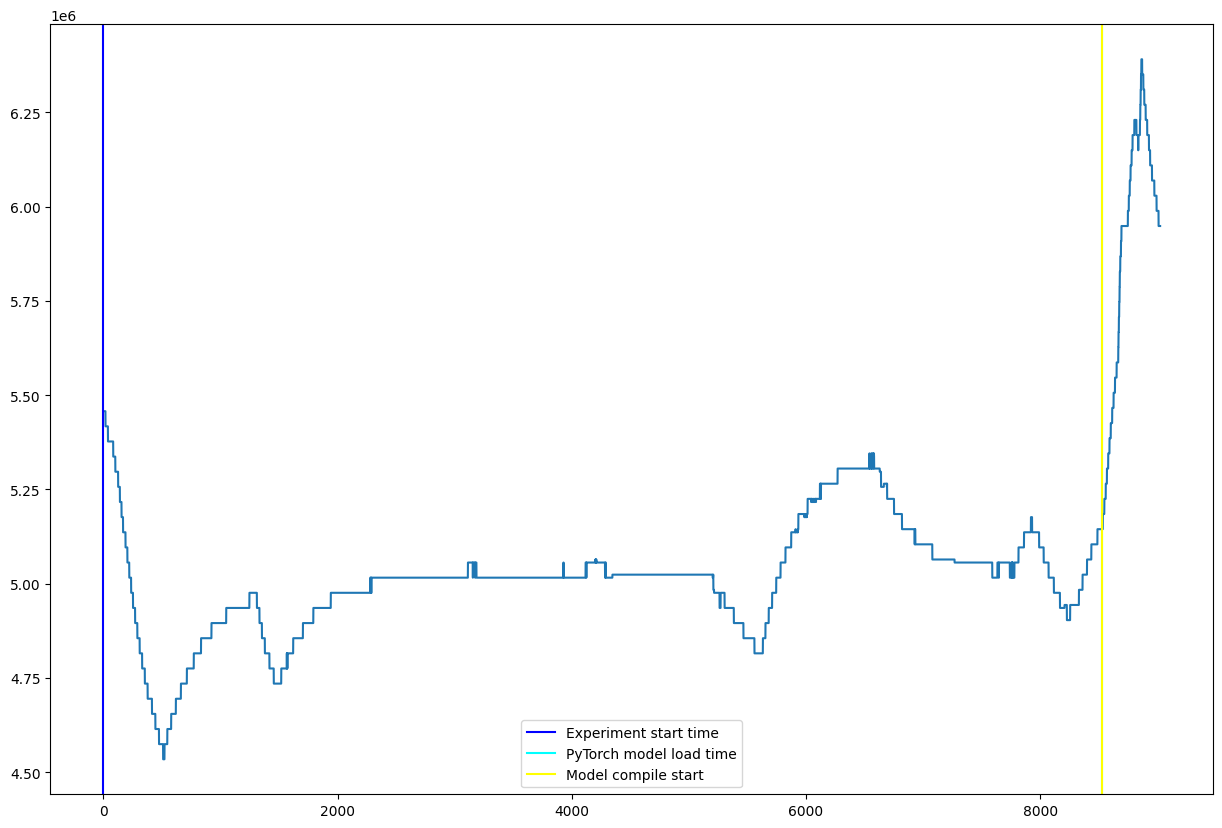

In [19]:
plt.figure(figsize=(15, 10))
plt.plot([power for (timestamp, power) in vgg19_power_data[:model_load_start_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(pytorch_load_end_index, color='cyan', label='PyTorch model load time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.legend()

This is the most interesting plot that shows all the things happening before the actual inference starts.

1. Load the PyTorch model and peparate it for converting it to TensorRT. -> **This is the part between blue and yellow line.**
2. Convert the PyTorch model to TensorRT model. -> **This is the part between yellow and red line**.
3. A delay of 10 seconds is added as a cooldown from compilation. -> **This is the part between red and green line**.
4. A warmup of 100 runs is pretty fast. -> **This is the part between purple and green line**. It is fast so the lines are overlapping.

In the following section we break down the actual time taken by these processes as well.

We can also get the power consumed when the model is loaded which is 3rd part above between red and green line.
We get that power value to be `4253568.0`.

So we have power value 

- When jeston is idle : 4174621
- When TRT model is loaded: 4253568
- When inference is ran for 3000 runs: 4253568


> **A different and higher value is observed for VGG19 compared to VGG16 when TRT model is loaded.**

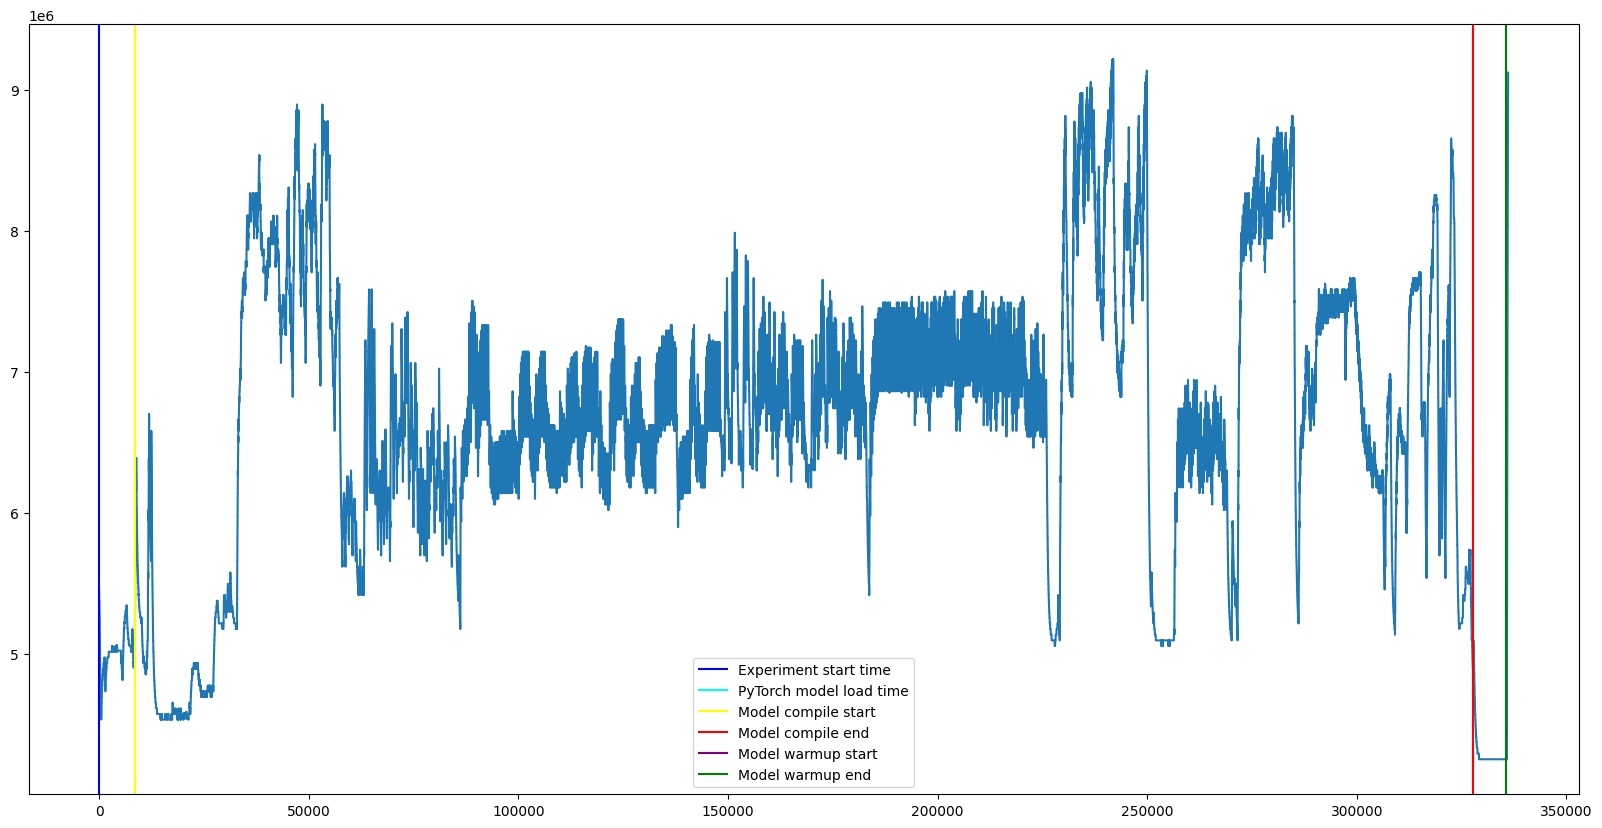

In [20]:
plt.figure(figsize=(20, 10))
plt.plot([power for (timestamp, power) in vgg19_power_data[:warmup_end_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(pytorch_load_end_index, color='cyan', label='PyTorch model load time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.axvline(model_load_end_index, color='red', label='Model compile end')
plt.axvline(warmup_start_index, color='purple', label='Model warmup start')
plt.axvline(warmup_end_index, color='green', label='Model warmup end')
plt.legend()

In [21]:
print(f'Time taken to download and load the pytorch model: {(pytorch_load_end_time - experiment_start_time).total_seconds()} seconds')
print(f'Time taken to before the model compile starts and pytorch model is loaded: {(model_load_start_time - pytorch_load_end_time).total_seconds()} seconds')
print(f'Time taken to compile the TensorRT model: {(model_load_end_time - model_load_start_time).total_seconds()} seconds')
print(f'Sleep interval before the warmup starts: {(warmup_start_time - model_load_end_time).total_seconds()} seconds')
print(f'Time taken to run 100 runs of the warmup: {(warmup_end_time - warmup_start_time).total_seconds()} seconds')

Time taken to download and load the pytorch model: 12.0 seconds
Time taken to before the model compile starts and pytorch model is loaded: 0.0 seconds
Time taken to compile the TensorRT model: 415.0 seconds
Sleep interval before the warmup starts: 10.0 seconds
Time taken to run 100 runs of the warmup: 0.0 seconds


### Power cool down

This is the delay we introduce after the warmup ends and before the first iteration cycle beings for the benchmarking experiment.

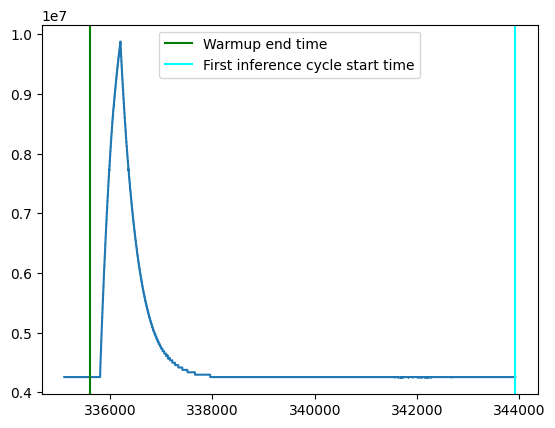

In [22]:
plt.plot(range(warmup_end_index-500, 343918), [power for (timestamp, power) in vgg19_power_data[warmup_end_index-500:343918]])
plt.axvline(warmup_end_index, color='green', label='Warmup end time')
plt.axvline(343918, color='cyan', label='First inference cycle start time')
plt.legend()

### Inference cylces

Something else that is interesting is now the first cylce like the rest of the cycles has similar power profile for the inference.

By adding sufficient delays and allowing the power to cool down, we see that inference for 3000 runs consumes the same power for all cycles. 

> **The power consumed when the inference starts is different.**

> **The power at the end of inference is significantly higher than inference start.**

> **The power at the end of 1 second delay significantly lower than inference end.**

2025-01-22 16:26:40.598833 -> 2025-01-22 16:26:40.608662
2025-01-22 16:26:41.608662
Time taken by inference cycle 0: 0:00:00.009829
Iteration: 0, Power index: 343918 -> 343927
344713


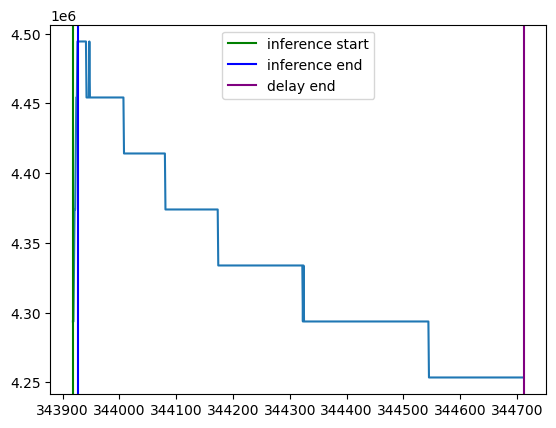

Power values:
Inference start: 4293696.0
Inference end: 4494336.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:41.616546 -> 2025-01-22 16:26:41.626712
2025-01-22 16:26:42.626712
Time taken by inference cycle 1: 0:00:00.010166
Iteration: 1, Power index: 344718 -> 344727
345513


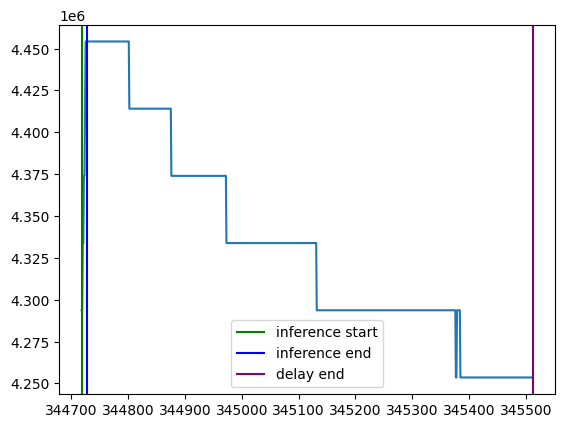

Power values:
Inference start: 4293696.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:42.629385 -> 2025-01-22 16:26:42.639243
2025-01-22 16:26:43.639243
Time taken by inference cycle 2: 0:00:00.009858
Iteration: 2, Power index: 345514 -> 345523
346309


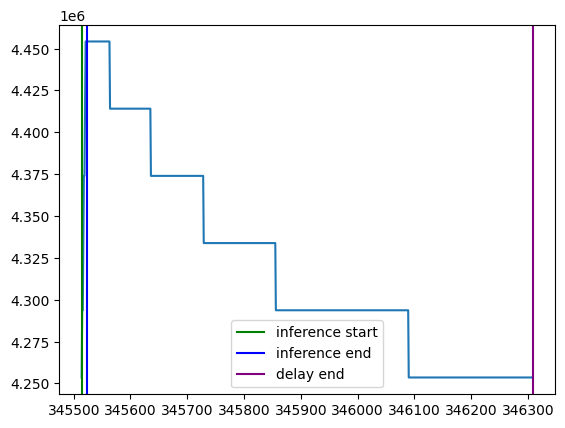

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:43.641886 -> 2025-01-22 16:26:43.651736
2025-01-22 16:26:44.651736
Time taken by inference cycle 3: 0:00:00.009850
Iteration: 3, Power index: 346311 -> 346319
347106


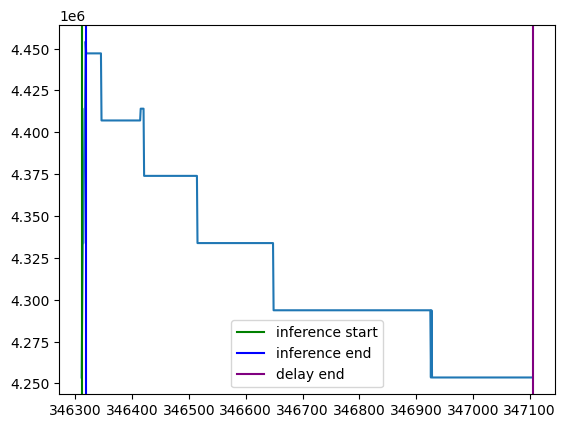

Power values:
Inference start: 4253568.0
Inference end: 4447104.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:44.654210 -> 2025-01-22 16:26:44.664092
2025-01-22 16:26:45.664092
Time taken by inference cycle 4: 0:00:00.009882
Iteration: 4, Power index: 347107 -> 347115
347901


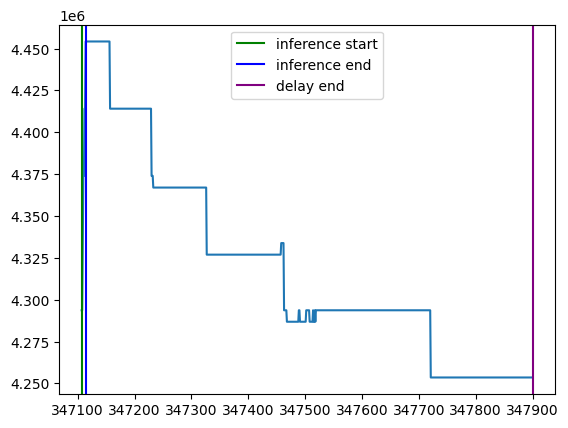

Power values:
Inference start: 4293696.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:45.666634 -> 2025-01-22 16:26:45.676465
2025-01-22 16:26:46.676465
Time taken by inference cycle 5: 0:00:00.009831
Iteration: 5, Power index: 347902 -> 347911
348696


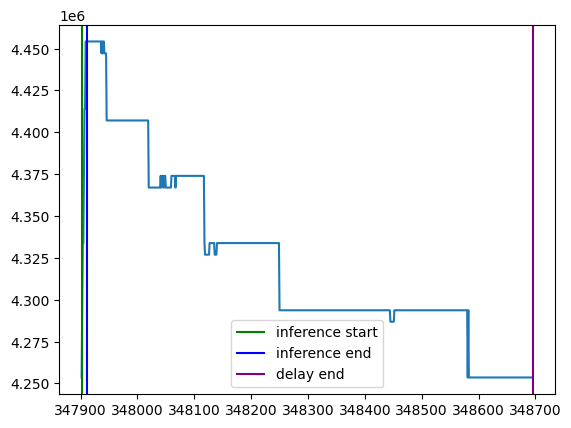

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:46.678956 -> 2025-01-22 16:26:46.688858
2025-01-22 16:26:47.688858
Time taken by inference cycle 6: 0:00:00.009902
Iteration: 6, Power index: 348697 -> 348706
349492


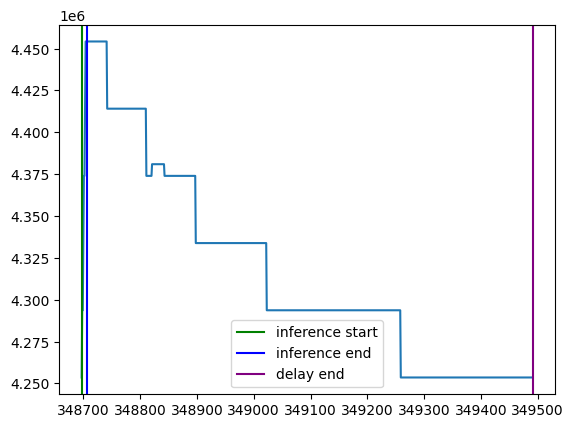

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:47.691396 -> 2025-01-22 16:26:47.701286
2025-01-22 16:26:48.701286
Time taken by inference cycle 7: 0:00:00.009890
Iteration: 7, Power index: 349493 -> 349501
350287


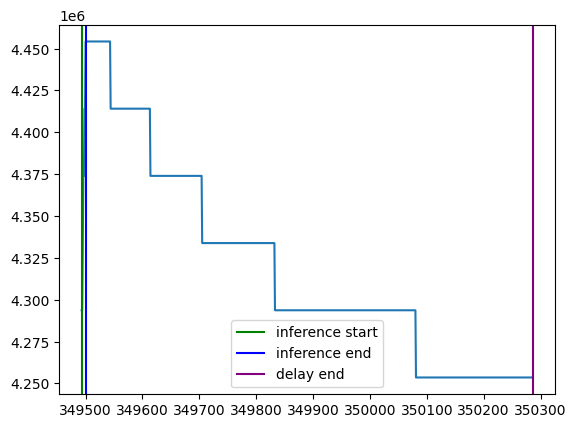

Power values:
Inference start: 4293696.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:48.703742 -> 2025-01-22 16:26:48.713614
2025-01-22 16:26:49.713614
Time taken by inference cycle 8: 0:00:00.009872
Iteration: 8, Power index: 350288 -> 350297
351083


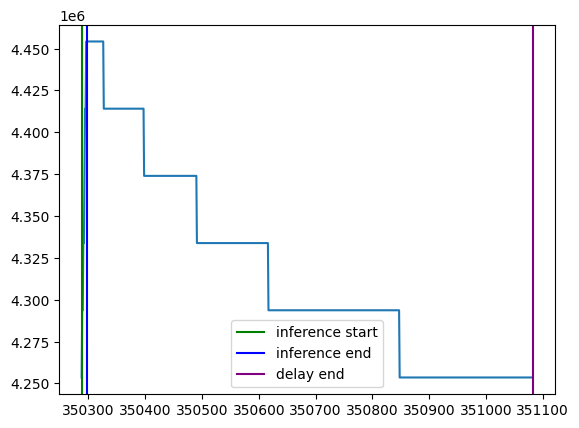

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:49.716118 -> 2025-01-22 16:26:49.725991
2025-01-22 16:26:50.725991
Time taken by inference cycle 9: 0:00:00.009873
Iteration: 9, Power index: 351084 -> 351093
351879


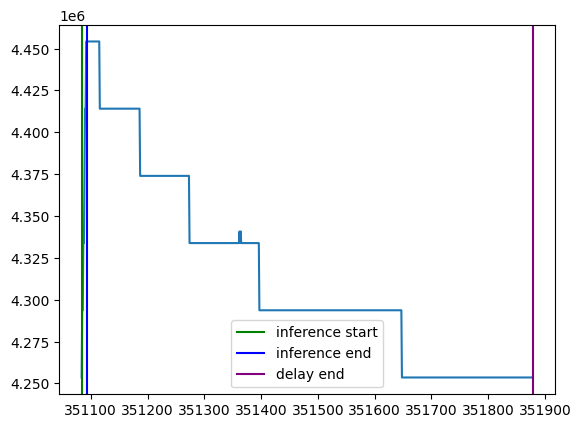

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:50.728494 -> 2025-01-22 16:26:50.738365
2025-01-22 16:26:51.738365
Time taken by inference cycle 10: 0:00:00.009871
Iteration: 10, Power index: 351879 -> 351888
352674


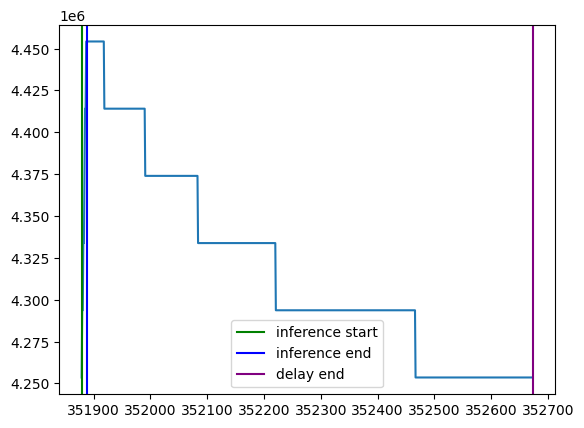

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:51.740880 -> 2025-01-22 16:26:51.750760
2025-01-22 16:26:52.750760
Time taken by inference cycle 11: 0:00:00.009880
Iteration: 11, Power index: 352675 -> 352684
353470


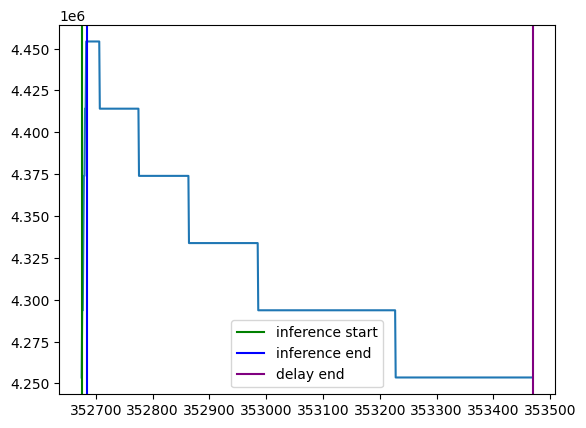

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:52.753267 -> 2025-01-22 16:26:52.763155
2025-01-22 16:26:53.763155
Time taken by inference cycle 12: 0:00:00.009888
Iteration: 12, Power index: 353471 -> 353479
354265


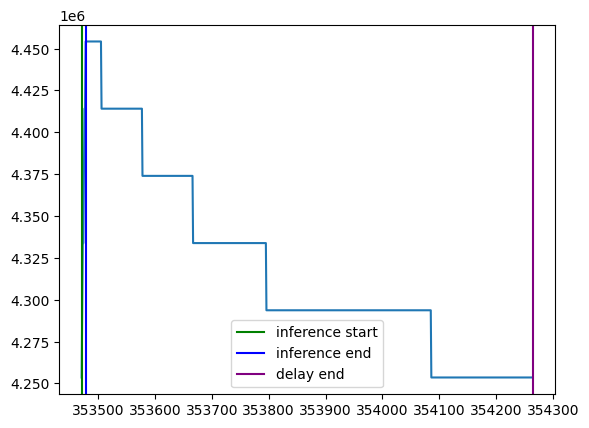

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:53.765764 -> 2025-01-22 16:26:53.775627
2025-01-22 16:26:54.775627
Time taken by inference cycle 13: 0:00:00.009863
Iteration: 13, Power index: 354266 -> 354275
355061


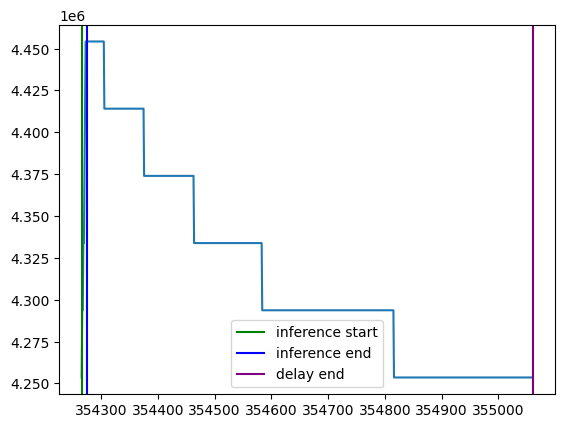

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 16:26:54.778104 -> 2025-01-22 16:26:54.787978
2025-01-22 16:26:55.787978
Time taken by inference cycle 14: 0:00:00.009874
Iteration: 14, Power index: 355062 -> 355071
355857


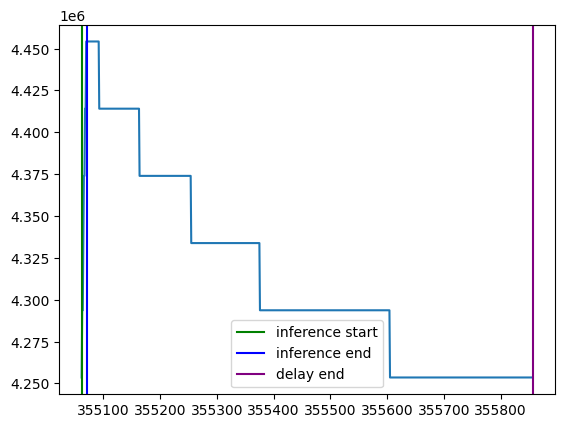

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------


In [23]:
for i in range(15):
    plot_inference_cycle_power(i, vgg19_power_data, vgg19_latency_data, DELAY)